In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append('..')
sys.path.append(os.path.abspath(os.path.join('..', 'magnet-pinn')))

In [3]:
import torch

from torch.utils.data import DataLoader

from magnet_pinn.data.transforms import Compose, Crop, GridPhaseShift
from magnet_pinn.data.grid import MagnetGridIterator

VAL_DIR = "../data/processed/batch_17/grid_voxel_size_4_data_type_float32"

augmentation = Compose(
    [
        Crop(crop_size=(100, 100, 100)),
        GridPhaseShift(num_coils=8)
    ]
)

val_set = MagnetGridIterator(VAL_DIR, transforms=augmentation, num_samples=2)
val_loader = DataLoader(val_set, batch_size=1, num_workers=2)

In [ ]:
import einops

from mrifield.models import UNet3D
from mrifield.train.lit_mrifield import LitMRIField
from magnet_pinn.utils import StandardNormalizer

CKPT = "baseline_unet/qvnx449u/checkpoints/epoch=9-step=173750.ckpt"

model = UNet3D(in_channels=5, out_channels=12)

train_input_normalizer = StandardNormalizer.load_from_json("../results/normalization/train/input_normalization.json")
train_target_normalizer = StandardNormalizer.load_from_json("../results/normalization/train/target_normalization.json")
val_input_normalizer = StandardNormalizer.load_from_json("../results/normalization/val/input_normalization.json")
val_target_normalizer = StandardNormalizer.load_from_json("../results/normalization/val/target_normalization.json")

trained_model = LitMRIField.load_from_checkpoint(
    CKPT,
    model=model,
    train_input_normalizer=train_input_normalizer,
    train_target_normalizer=train_target_normalizer,
    val_input_normalizer=val_input_normalizer,
    val_target_normalizer=val_target_normalizer
)

trained_model.eval()

In [71]:
sample = next(iter(val_loader))

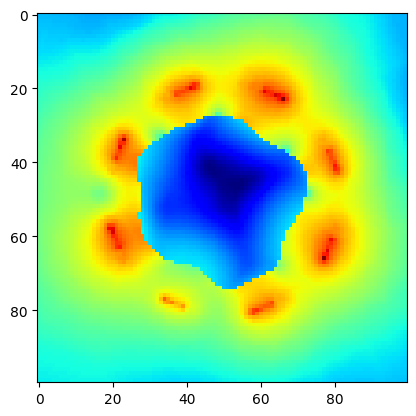

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Ground truth

re = sample['field'][0, 0, 0, :, :, :, :]
im = sample['field'][0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].cpu().numpy(), cmap='jet', norm='log')
plt.show()

torch.Size([1, 12, 100, 100, 100])


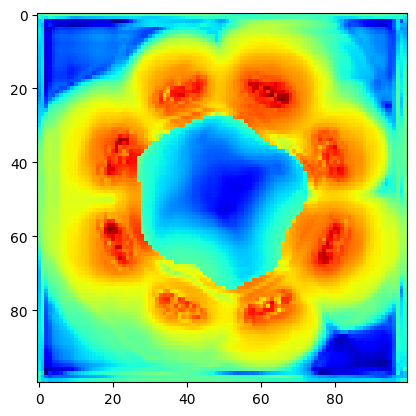

In [73]:
# Prediction

inputs = sample['input']
coils = sample['coils']

x = val_input_normalizer(torch.cat([inputs, coils], dim=1))

pred = val_target_normalizer.inverse(trained_model(x))
pred = einops.rearrange(pred, 'b (he reim xyz) ... -> b he reim xyz ...', he=2, reim=2, xyz=3)

re = pred[0, 0, 0, :, :, :, :]
im = pred[0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].detach().numpy(), cmap='jet', norm='log')
plt.show()